In [11]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import structural_similarity as ssim

root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.append(str(root))

from src.ME import ImageMetrics
from src.gregor import gregor_stage_comparison
from src.level_analysis import (
    compute_level_results,
    discover_level_dirs,
    plot_level_pairwise_trajectories,
    plot_level_scalar_summary,
    print_level_summary,
)
from src.nonlinear_probe import nonlinear_probe_image_decodability
from src.probe import probe_image_decodability
from src.process_images import load_noise_sets_from_dir

figures_dir = root / "figures"
figures_dir.mkdir(exist_ok=True)


In [12]:
base_dir = root / "data" / "individual" / "pmca-1-5"
target_dir = root / "data" / "targets"
level_dirs = discover_level_dirs(base_dir)
print("Discovered levels:", [p.name for p in level_dirs])
print("Using canonical targets from:", target_dir)

results = compute_level_results(base_dir, target_dir=target_dir, bins=128, probe_alpha=1e-3)
print_level_summary(results)

Discovered levels: ['lvl1', 'lvl2', 'lvl3', 'lvl4']
Using canonical targets from: c:\Users\jakob\Documents\work\PhD\SIREN\data\targets
level     pair_ssim   pair_nmi   int_ssim    int_nmi  fourier_nmi  gregor_mi   probe_r2
---------------------------------------------------------------------------------------
lvl1          0.134      0.159      0.407      0.286        0.621      6.254     -0.021
lvl2          0.180      0.177      0.192      0.188        0.549      6.326      0.197
lvl3          0.072      0.176      0.208      0.203        0.452      6.743     -0.020
lvl4          0.083      0.169      0.142      0.184        0.434      7.053      0.039


In [13]:

# Noise baseline — run across all noise sets and collect stats for reference lines
target_ref = results["levels"][results["level_names"][0]]["target"]
noise_root = root / "data" / "noises"
noise_sets, noise_names = load_noise_sets_from_dir(noise_root)

# Keep only the same number of images as target if needed.
if noise_sets.shape[1] < target_ref.shape[0]:
    raise ValueError(f"Noise sets have fewer images ({noise_sets.shape[1]}) than target ({target_ref.shape[0]}).")
noise_sets = noise_sets[:, : target_ref.shape[0]]

if noise_sets.shape[2:] != target_ref.shape[1:]:
    from skimage.transform import resize
    target_h, target_w = target_ref.shape[1:3]
    resized = np.stack([
        np.stack([
            (resize(img, (target_h, target_w), anti_aliasing=True) * 255).astype(np.uint8)
            for img in noise_set
        ])
        for noise_set in noise_sets
    ])
    noise_sets = resized

n = target_ref.shape[0]
i_idx, j_idx = np.triu_indices(n, k=1)

noise_cross_runs = []
noise_pairwise_ssim_runs = []
noise_gregor_runs = []
noise_probe_runs = []
noise_nonlinear_probe_runs = []

for noisy_s in noise_sets:
    cross = ImageMetrics(noisy_s, target_ref, bins=128).cross_stage_metrics()
    noise_cross_runs.append(cross)

    noise_pairwise_ssim_runs.append(np.array([
        ssim(noisy_s[i], noisy_s[j], channel_axis=-1, data_range=255)
        for i, j in zip(i_idx, j_idx)
    ]))

    noise_gregor_runs.append(gregor_stage_comparison(noisy_s, target_ref, rgb_bins=32))
    noise_probe_runs.append(probe_image_decodability(noisy_s, target_ref, alpha=1e-3, add_coords=False))
    noise_nonlinear_probe_runs.append(nonlinear_probe_image_decodability(noisy_s, target_ref, alpha=1e-3, add_coords=False))

noise_baseline = {
    # Cross-stage (pre[k] vs target[k]) metrics
    "pair_ssim_mean": float(np.mean([r["mean_pair_ssim"] for r in noise_cross_runs])),
    "pair_ssim_std": float(np.std([r["mean_pair_ssim"] for r in noise_cross_runs])),
    "pair_nmi_mean": float(np.mean([r["mean_pair_nmi"] for r in noise_cross_runs])),
    "pair_nmi_std": float(np.std([r["mean_pair_nmi"] for r in noise_cross_runs])),
    "pair_fourier_nmi_mean": float(np.mean([r["mean_pair_fourier_nmi"] for r in noise_cross_runs])),
    "pair_fourier_nmi_std": float(np.std([r["mean_pair_fourier_nmi"] for r in noise_cross_runs])),
    # Cohort (internal) metrics
    "internal_nmi_mean": float(np.mean([r["pre_internal_nmi_mean"] for r in noise_cross_runs])),
    "internal_nmi_std": float(np.std([r["pre_internal_nmi_mean"] for r in noise_cross_runs])),
    "internal_ssim_mean": float(np.mean([v.mean() for v in noise_pairwise_ssim_runs])),
    "internal_ssim_std": float(np.std([v.mean() for v in noise_pairwise_ssim_runs])),
    "fourier_internal_nmi_mean": float(np.mean([r["pre_fourier_internal_nmi_mean"] for r in noise_cross_runs])),
    "fourier_internal_nmi_std": float(np.std([r["pre_fourier_internal_nmi_mean"] for r in noise_cross_runs])),
    "fourier_entropy_mean": float(np.mean([r["pre_fourier_entropy_mean"] for r in noise_cross_runs])),
    "fourier_entropy_std": float(np.std([r["pre_fourier_entropy_mean"] for r in noise_cross_runs])),
    "pairwise_nmi": np.mean([r["pre_pairwise_nmi"][i_idx, j_idx] for r in noise_cross_runs], axis=0),
    "pairwise_ssim": np.mean(noise_pairwise_ssim_runs, axis=0),
    "pairwise_fourier_nmi": np.mean([r["pre_fourier_pairwise_nmi"][i_idx, j_idx] for r in noise_cross_runs], axis=0),
    # Gregor
    "gregor_mi_mean": float(np.mean([r["pre_mi_mean"] for r in noise_gregor_runs])),
    "gregor_mi_std": float(np.std([r["pre_mi_mean"] for r in noise_gregor_runs])),
    "gregor_uniqueness_mean": float(np.mean([r["pre_uniqueness_mean"] for r in noise_gregor_runs])),
    "gregor_uniqueness_std": float(np.std([r["pre_uniqueness_mean"] for r in noise_gregor_runs])),
    # Probes
    "probe_r2_mean": float(np.mean([r["mean_r2"] for r in noise_probe_runs])),
    "probe_r2_std": float(np.std([r["mean_r2"] for r in noise_probe_runs])),
    "probe_mse_mean": float(np.mean([r["mean_mse"] for r in noise_probe_runs])),
    "probe_mse_std": float(np.std([r["mean_mse"] for r in noise_probe_runs])),
    "nonlinear_probe_r2_mean": float(np.mean([r["mean_r2"] for r in noise_nonlinear_probe_runs])),
    "nonlinear_probe_r2_std": float(np.std([r["mean_r2"] for r in noise_nonlinear_probe_runs])),
    "nonlinear_probe_mse_mean": float(np.mean([r["mean_mse"] for r in noise_nonlinear_probe_runs])),
    "nonlinear_probe_mse_std": float(np.std([r["mean_mse"] for r in noise_nonlinear_probe_runs])),
}

print("Noise baseline loaded from:", noise_root)
print("Noise sets:", noise_names)
print("Noise cross-stage SSIM mean:", f"{noise_baseline['pair_ssim_mean']:.4f}")
print("Noise cross-stage NMI mean:", f"{noise_baseline['pair_nmi_mean']:.4f}")
print("Noise cross-stage Fourier NMI mean:", f"{noise_baseline['pair_fourier_nmi_mean']:.4f}")
print("Noise internal NMI mean:", f"{noise_baseline['internal_nmi_mean']:.4f}")
print("Noise Fourier internal NMI mean:", f"{noise_baseline['fourier_internal_nmi_mean']:.4f}")
print("Noise Gregor MI mean:", f"{noise_baseline['gregor_mi_mean']:.4f}")
print("Noise Linear Probe R² mean:", f"{noise_baseline['probe_r2_mean']:.4f}")
print("Noise Nonlinear Probe R² mean:", f"{noise_baseline['nonlinear_probe_r2_mean']:.4f}")


Noise baseline loaded from: c:\Users\jakob\Documents\work\PhD\SIREN\data\noises
Noise sets: ['noise01', 'noise02', 'noise03', 'noise04', 'noise05']
Noise cross-stage SSIM mean: 0.0783
Noise cross-stage NMI mean: 0.1139
Noise cross-stage Fourier NMI mean: 0.1928
Noise internal NMI mean: 0.2143
Noise Fourier internal NMI mean: 0.5106
Noise Gregor MI mean: 7.3280
Noise Linear Probe R² mean: -0.3062
Noise Nonlinear Probe R² mean: -0.4382


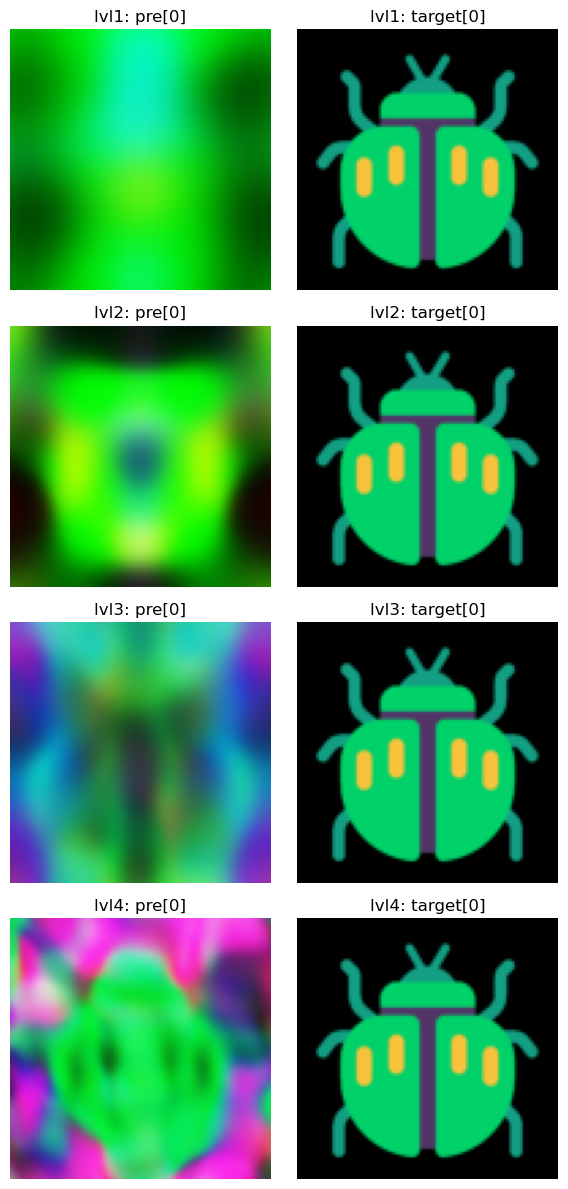

In [14]:
# Quick qualitative check: first sample from each level
level_names = results["level_names"]
fig, axes = plt.subplots(len(level_names), 2, figsize=(6, 3 * len(level_names)))
if len(level_names) == 1:
    axes = np.array([axes])

for row, level_name in enumerate(level_names):
    level = results["levels"][level_name]
    axes[row, 0].imshow(level["pre"][0].astype(np.uint8))
    axes[row, 0].set_title(f"{level_name}: pre[0]")
    axes[row, 1].imshow(level["target"][0].astype(np.uint8))
    axes[row, 1].set_title(f"{level_name}: target[0]")
    axes[row, 0].axis("off")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.savefig(figures_dir / "qualitative_check.pdf", bbox_inches="tight")
plt.show()


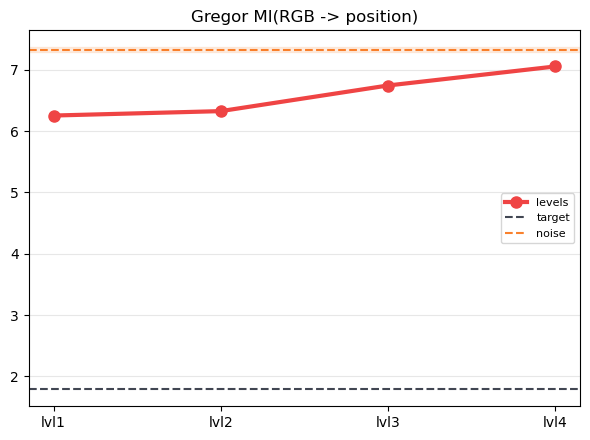

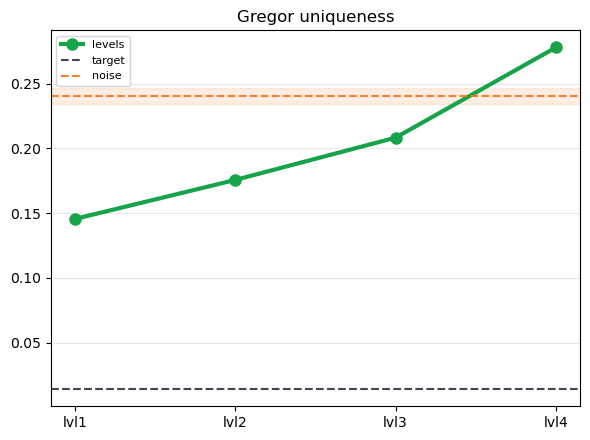

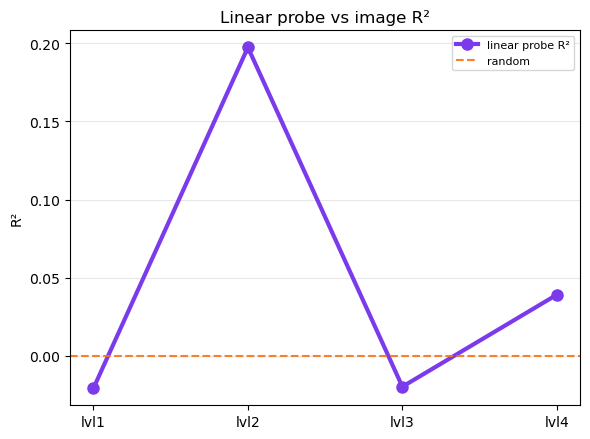

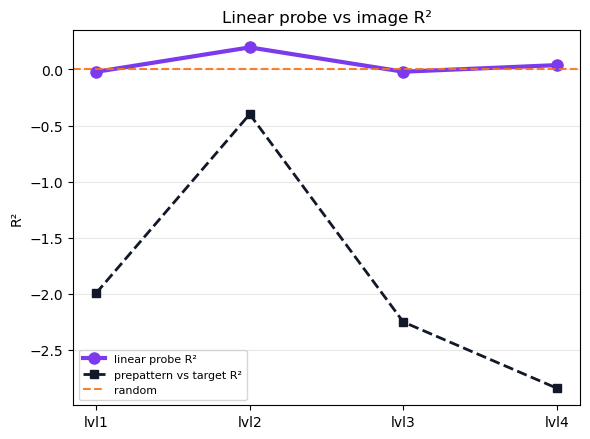

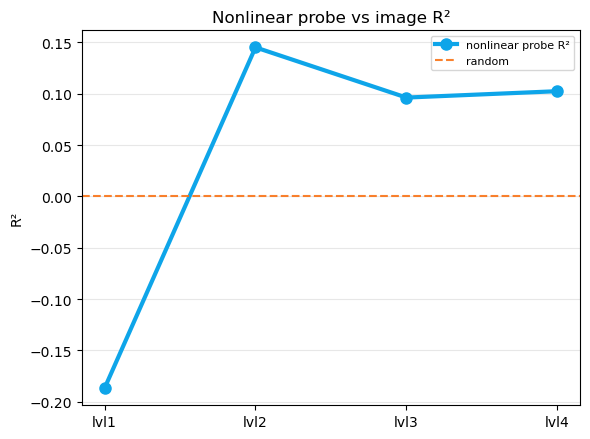

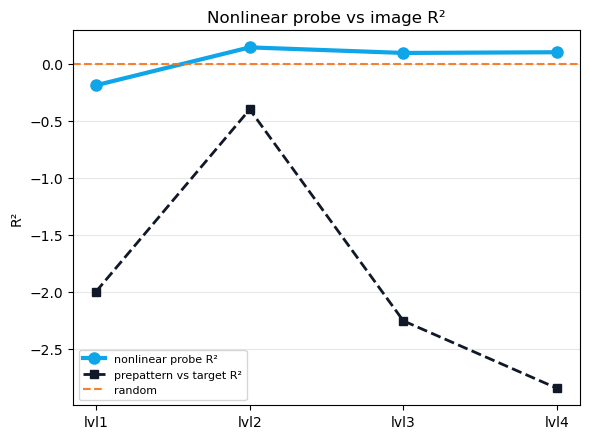

Gregor + probe summary (levels):
  lvl1: Gregor MI=6.2536, uniq=0.1455, image->target R²=-1.9972, linear R²=-0.0208, linear MSE=0.082995, nonlinear R²=-0.1870, nonlinear MSE=0.099200
  lvl2: Gregor MI=6.3255, uniq=0.1756, image->target R²=-0.3991, linear R²=0.1974, linear MSE=0.065281, nonlinear R²=0.1452, nonlinear MSE=0.071113
  lvl3: Gregor MI=6.7434, uniq=0.2082, image->target R²=-2.2540, linear R²=-0.0198, linear MSE=0.080388, nonlinear R²=0.0963, nonlinear MSE=0.076069
  lvl4: Gregor MI=7.0534, uniq=0.2778, image->target R²=-2.8453, linear R²=0.0391, linear MSE=0.074005, nonlinear R²=0.1025, nonlinear MSE=0.074747


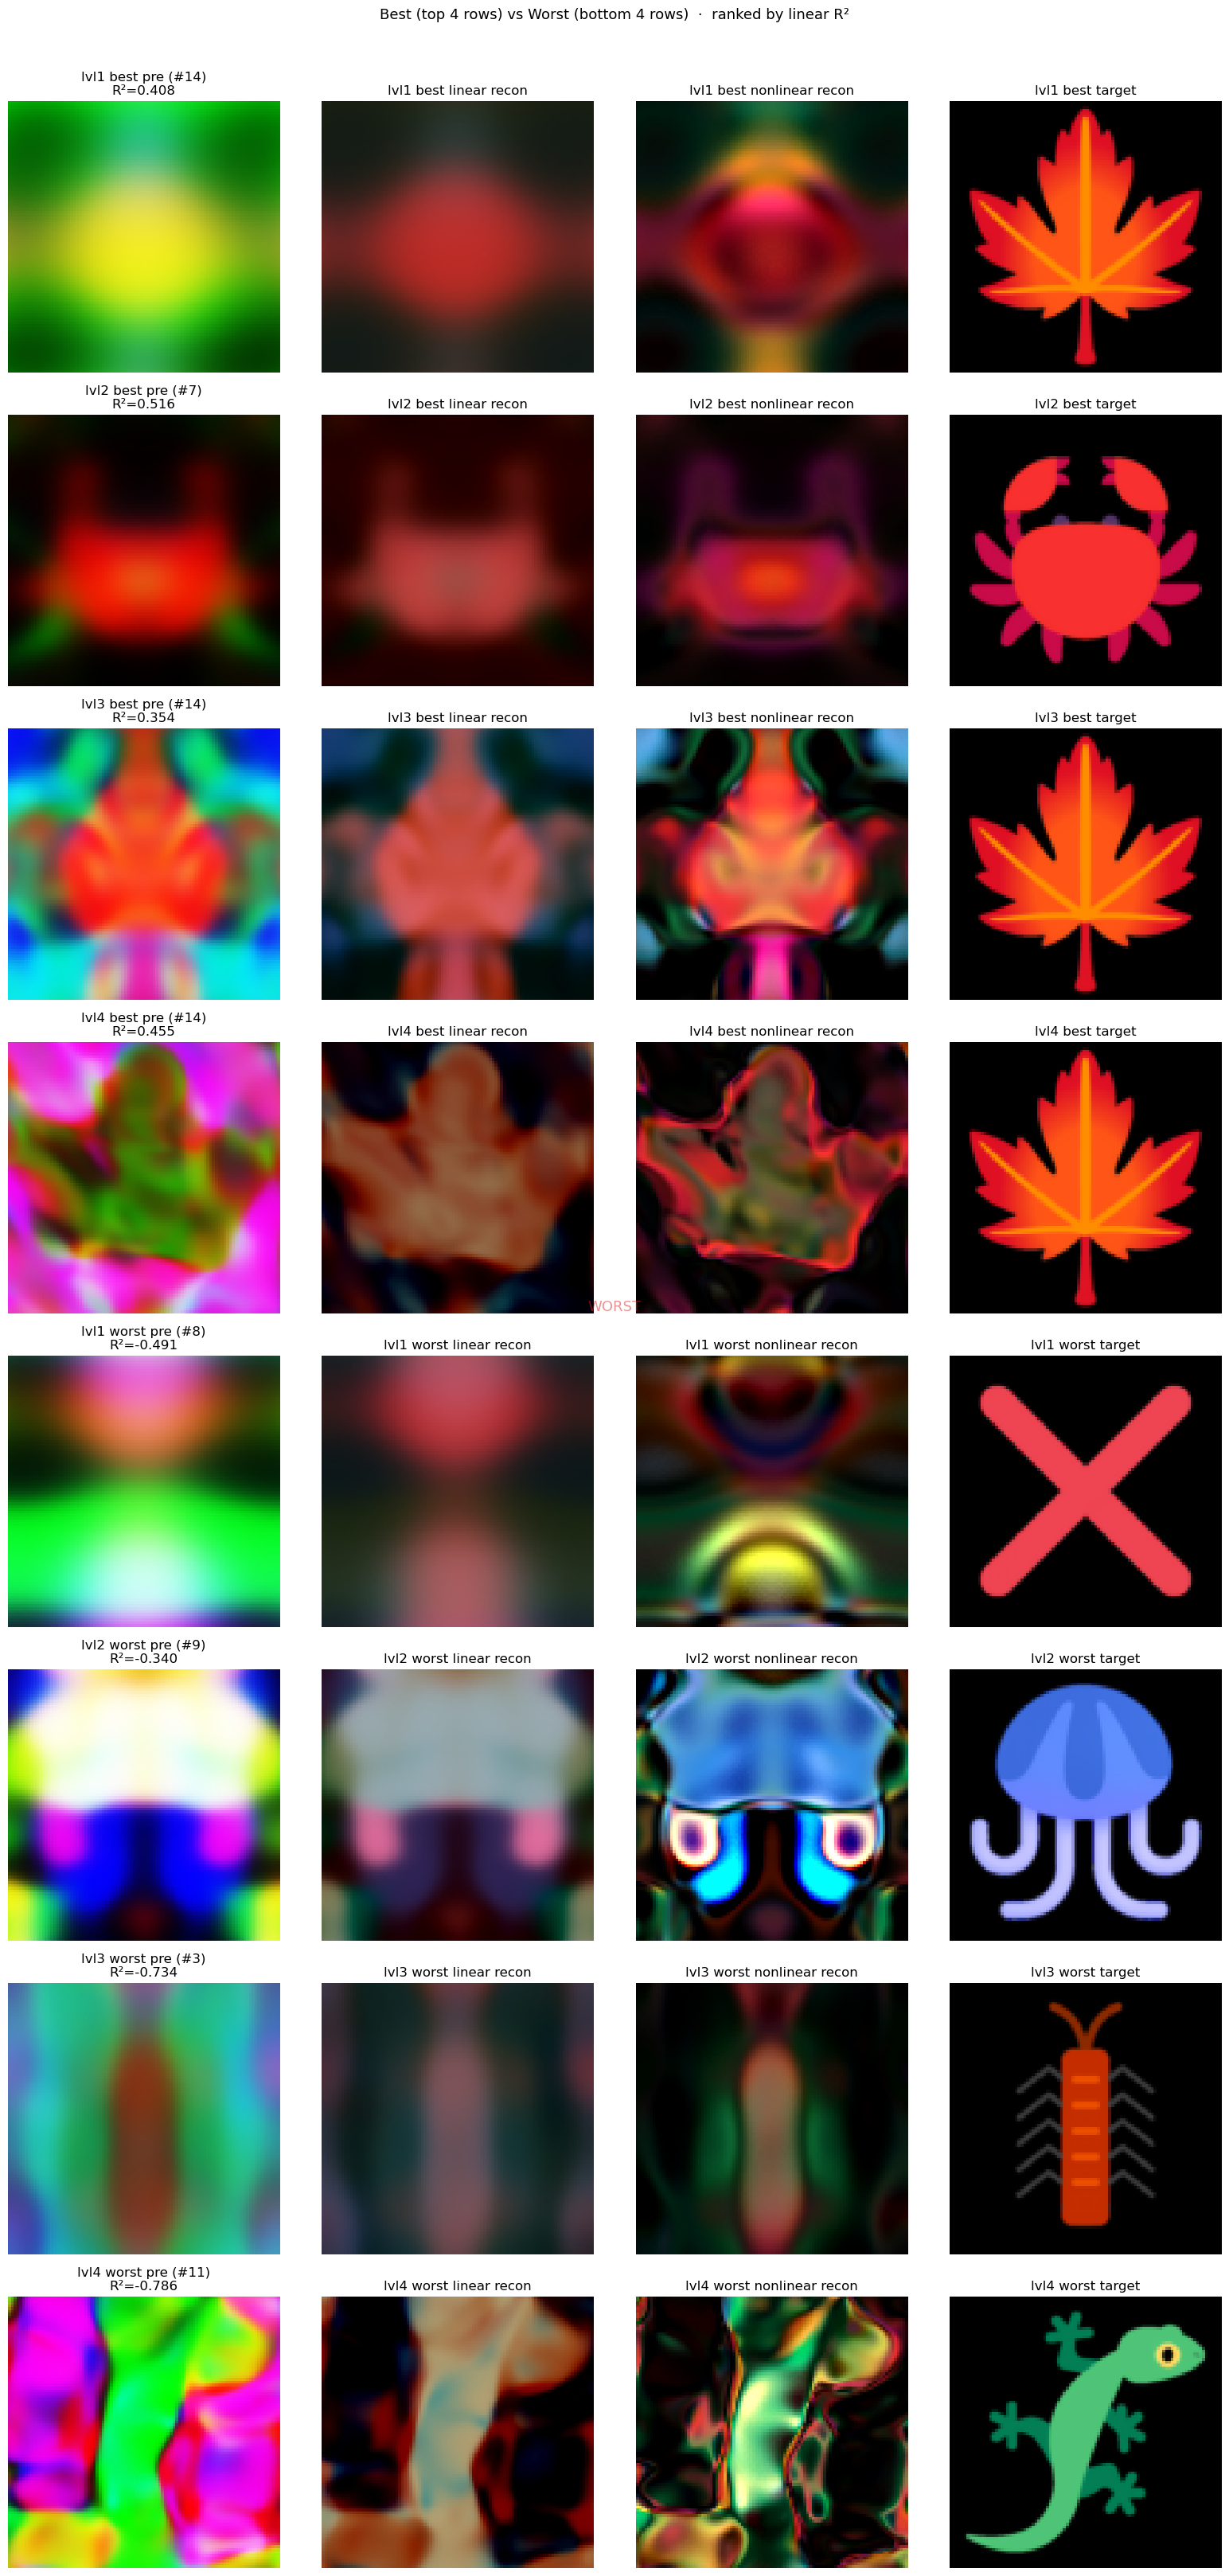

In [21]:

# Gregor + linear and nonlinear probe — levels on x-axis, noise as reference line
level_names = results["level_names"]
x = np.arange(len(level_names))

def mean_image_to_target_r2(images, targets):
    images_f = images.astype(np.float32) / 255.0
    targets_f = targets.astype(np.float32) / 255.0
    r2_values = []
    for img, tgt in zip(images_f, targets_f):
        pred_flat = img.reshape(-1, img.shape[-1])
        true_flat = tgt.reshape(-1, tgt.shape[-1])
        ss_res = float(np.sum((true_flat - pred_flat) ** 2))
        ss_tot = float(np.sum((true_flat - true_flat.mean(axis=0, keepdims=True)) ** 2))
        r2_values.append(1.0 - (ss_res / ss_tot) if ss_tot > 0 else 0.0)
    return float(np.mean(r2_values)), np.array(r2_values, dtype=np.float32)

gregor_mi = [results["levels"][k]["gregor"]["pre_mi_mean"] for k in level_names]
gregor_unique = [results["levels"][k]["gregor"]["pre_uniqueness_mean"] for k in level_names]
target_gregor_mi = results["levels"][level_names[0]]["gregor"]["target_mi_mean"]
target_gregor_unique = results["levels"][level_names[0]]["gregor"]["target_uniqueness_mean"]

probe_r2 = [results["levels"][k]["probe"]["mean_r2"] for k in level_names]
probe_mse = [results["levels"][k]["probe"]["mean_mse"] for k in level_names]
nl_probe_r2 = [results["levels"][k]["nonlinear_probe"]["mean_r2"] for k in level_names]
nl_probe_mse = [results["levels"][k]["nonlinear_probe"]["mean_mse"] for k in level_names]
image_target_r2 = [
    mean_image_to_target_r2(results["levels"][k]["pre"], results["levels"][k]["target"])[0]
    for k in level_names
]

# Gregor MI (individual figure)
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
ax.plot(x, gregor_mi, "o-", linewidth=3, markersize=8, color="#ef4444", label="levels")
ax.axhline(target_gregor_mi, linestyle="--", color="#111827", alpha=0.8, label="target")
nm, ns = noise_baseline["gregor_mi_mean"], noise_baseline["gregor_mi_std"]
ax.axhline(nm, linestyle="--", color="#f97316", alpha=0.9, label="noise")
ax.axhspan(nm - ns, nm + ns, alpha=0.12, color="#f97316")
ax.set_xticks(x)
ax.set_xticklabels(level_names)
ax.set_title("Gregor MI(RGB -> position)")
ax.grid(alpha=0.3, axis="y")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(figures_dir / "gregor_mi.pdf", bbox_inches="tight")
plt.show()

# Gregor uniqueness (individual figure)
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
ax.plot(x, gregor_unique, "o-", linewidth=3, markersize=8, color="#16a34a", label="levels")
ax.axhline(target_gregor_unique, linestyle="--", color="#111827", alpha=0.8, label="target")
nm, ns = noise_baseline["gregor_uniqueness_mean"], noise_baseline["gregor_uniqueness_std"]
ax.axhline(nm, linestyle="--", color="#f97316", alpha=0.9, label="noise")
ax.axhspan(nm - ns, nm + ns, alpha=0.12, color="#f97316")
ax.set_xticks(x)
ax.set_xticklabels(level_names)
ax.set_title("Gregor uniqueness")
ax.grid(alpha=0.3, axis="y")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(figures_dir / "gregor_uniqueness.pdf", bbox_inches="tight")
plt.show()

# Linear probe R^2 (with and without prepattern-vs-target)
for include_overlay in [False, True]:
    fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
    ax.plot(x, probe_r2, "o-", linewidth=3, markersize=8, color="#7c3aed", label="linear probe R²")
    if include_overlay:
        ax.plot(x, image_target_r2, "s--", linewidth=2, markersize=6, color="#111827", label="prepattern vs target R²")
    nm_r2, ns_r2 = noise_baseline["probe_r2_mean"], noise_baseline["probe_r2_std"]
    # ax.axhline(nm_r2, linestyle="--", color="#f97316", alpha=0.9, label="noise probe R²")
    ax.axhline(0, linestyle="--", color="#f97316", alpha=0.9, label="random")
    # ax.axhspan(nm_r2 - ns_r2, nm_r2 + ns_r2, alpha=0.12, color="#f97316")
    ax.set_xticks(x)
    ax.set_xticklabels(level_names)
    ax.set_title("Linear probe vs image R²")
    ax.set_ylabel("R²")
    ax.grid(alpha=0.3, axis="y")
    ax.legend(fontsize=8)
    plt.tight_layout()
    suffix = "with_prepattern" if include_overlay else "without_prepattern"
    plt.savefig(figures_dir / f"linear_probe_r2_{suffix}.pdf", bbox_inches="tight")
    plt.show()

# Nonlinear probe R^2 (with and without prepattern-vs-target)
for include_overlay in [False, True]:
    fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
    ax.plot(x, nl_probe_r2, "o-", linewidth=3, markersize=8, color="#0ea5e9", label="nonlinear probe R²")
    if include_overlay:
        ax.plot(x, image_target_r2, "s--", linewidth=2, markersize=6, color="#111827", label="prepattern vs target R²")
    nm_r2, ns_r2 = noise_baseline["nonlinear_probe_r2_mean"], noise_baseline["nonlinear_probe_r2_std"]
    # ax.axhline(nm_r2, linestyle="--", color="#f97316", alpha=0.9, label="noise probe R²")
    ax.axhline(0, linestyle="--", color="#f97316", alpha=0.9, label="random")
    # ax.axhspan(nm_r2 - ns_r2, nm_r2 + ns_r2, alpha=0.12, color="#f97316")
    ax.set_xticks(x)
    ax.set_xticklabels(level_names)
    ax.set_title("Nonlinear probe vs image R²")
    ax.set_ylabel("R²")
    ax.grid(alpha=0.3, axis="y")
    ax.legend(fontsize=8)
    plt.tight_layout()
    suffix = "with_prepattern" if include_overlay else "without_prepattern"
    plt.savefig(figures_dir / f"nonlinear_probe_r2_{suffix}.pdf", bbox_inches="tight")
    plt.show()

print("Gregor + probe summary (levels):")
for k, img_r2 in zip(level_names, image_target_r2):
    print(
        f"  {k}: Gregor MI={results['levels'][k]['gregor']['pre_mi_mean']:.4f}, "
        f"uniq={results['levels'][k]['gregor']['pre_uniqueness_mean']:.4f}, "
        f"image->target R²={img_r2:.4f}, "
        f"linear R²={results['levels'][k]['probe']['mean_r2']:.4f}, "
        f"linear MSE={results['levels'][k]['probe']['mean_mse']:.6f}, "
        f"nonlinear R²={results['levels'][k]['nonlinear_probe']['mean_r2']:.4f}, "
        f"nonlinear MSE={results['levels'][k]['nonlinear_probe']['mean_mse']:.6f}"
    )

# --------------------------------------------------------------------------
# Per-level best/worst image grid
#   Layout: all BEST rows first, then all WORST rows.
#   Each row: pre | linear recon | nonlinear recon | target
#   Best/worst ranked by linear R² (one shared index per level).
# --------------------------------------------------------------------------
n_levels = len(level_names)
n_rows = 2 * n_levels          # n_levels best rows + n_levels worst rows
col_labels = ["pre", "linear recon", "nonlinear recon", "target"]
n_cols = len(col_labels)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for i, level_name in enumerate(level_names):
    r2_lin = results["levels"][level_name]["probe"]["r2_values"]
    best_idx = int(np.argmax(r2_lin))
    worst_idx = int(np.argmin(r2_lin))

    lin_preds = results["levels"][level_name]["probe"]["predictions"]       # float [0,1]
    nl_preds  = results["levels"][level_name]["nonlinear_probe"]["predictions"]  # float [0,1]
    pre       = results["levels"][level_name]["pre"]
    target    = results["levels"][level_name]["target"]

    # Best row  -> row i
    best_row = i
    axes[best_row, 0].imshow(pre[best_idx].astype(np.uint8))
    axes[best_row, 0].set_title(f"{level_name} best pre (#{best_idx})\nR²={r2_lin[best_idx]:.3f}")
    axes[best_row, 1].imshow(np.clip(lin_preds[best_idx], 0, 1))
    axes[best_row, 1].set_title(f"{level_name} best linear recon")
    axes[best_row, 2].imshow(np.clip(nl_preds[best_idx], 0, 1))
    axes[best_row, 2].set_title(f"{level_name} best nonlinear recon")
    axes[best_row, 3].imshow(target[best_idx].astype(np.uint8))
    axes[best_row, 3].set_title(f"{level_name} best target")

    # Worst row -> row n_levels + i
    worst_row = n_levels + i
    axes[worst_row, 0].imshow(pre[worst_idx].astype(np.uint8))
    axes[worst_row, 0].set_title(f"{level_name} worst pre (#{worst_idx})\nR²={r2_lin[worst_idx]:.3f}")
    axes[worst_row, 1].imshow(np.clip(lin_preds[worst_idx], 0, 1))
    axes[worst_row, 1].set_title(f"{level_name} worst linear recon")
    axes[worst_row, 2].imshow(np.clip(nl_preds[worst_idx], 0, 1))
    axes[worst_row, 2].set_title(f"{level_name} worst nonlinear recon")
    axes[worst_row, 3].imshow(target[worst_idx].astype(np.uint8))
    axes[worst_row, 3].set_title(f"{level_name} worst target")

# Column headers via y-label on the leftmost column
for row_ax in axes[:, 0]:
    row_ax.set_ylabel("pre ->", fontsize=9)

# Draw a horizontal divider line between best and worst groups using a suptitle annotation
fig.text(0.5, 0.5, "WORST", ha="center", va="center",
         fontsize=13, color="#dc2626", alpha=0.5,
         transform=fig.transFigure)

fig.suptitle(
    f"Best (top {n_levels} rows) vs Worst (bottom {n_levels} rows)  ·  ranked by linear R²",
    fontsize=13, y=1.01
)

for row in axes:
    for col_ax in row:
        col_ax.axis("off")

plt.tight_layout()
plt.savefig(figures_dir / "best_worst_grid.pdf", bbox_inches="tight")
plt.show()


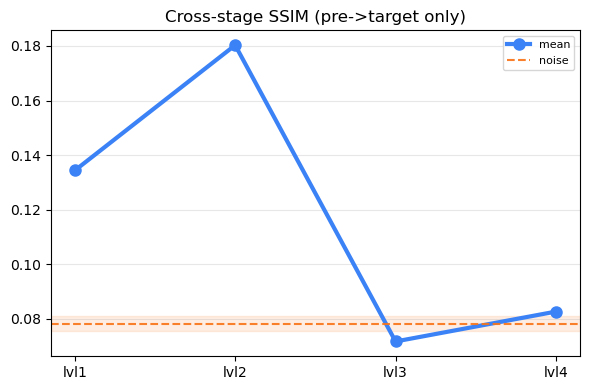

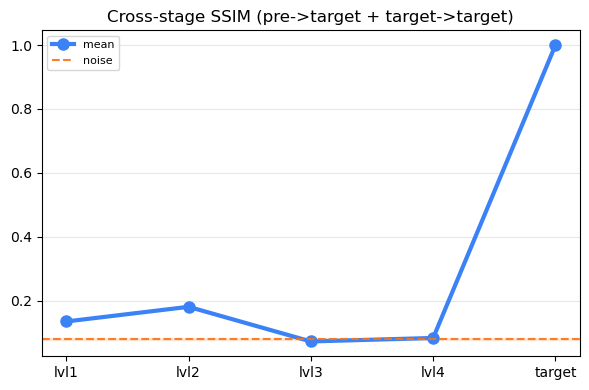

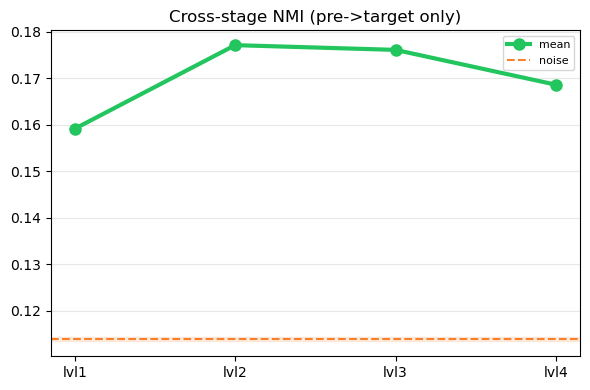

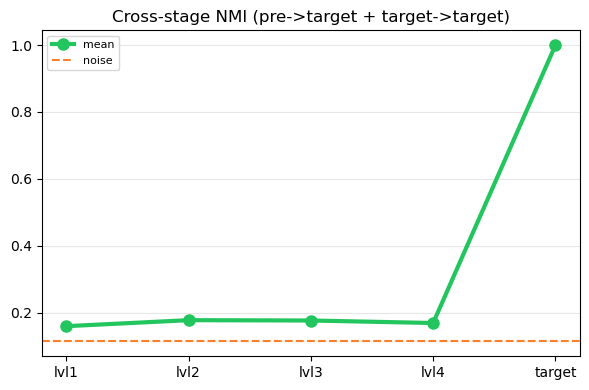

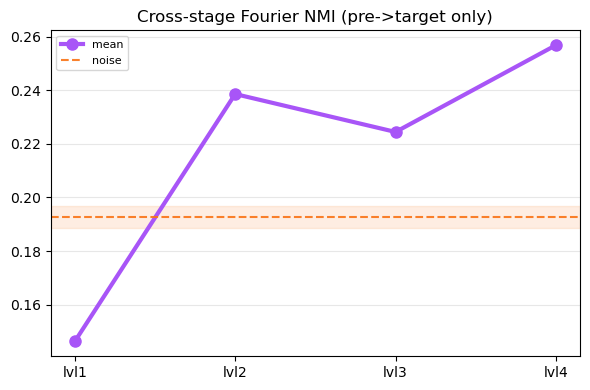

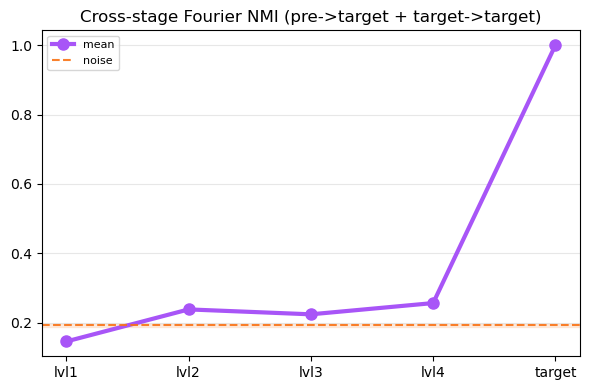

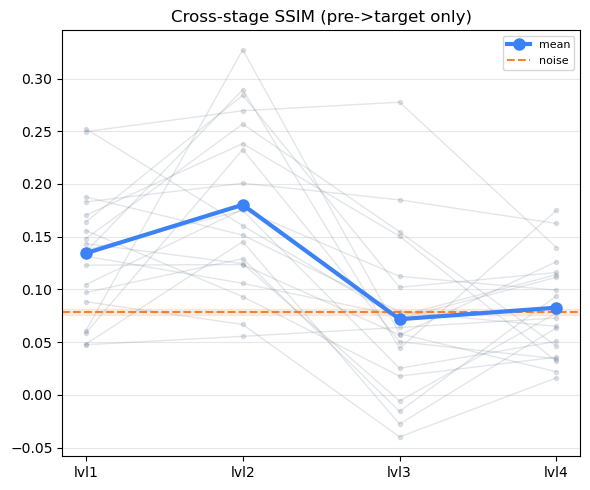

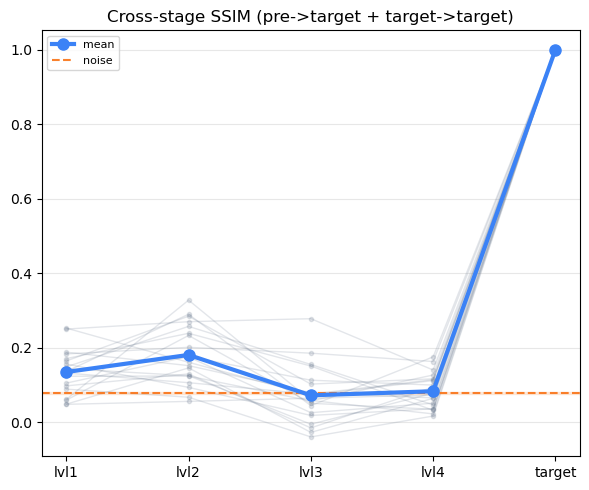

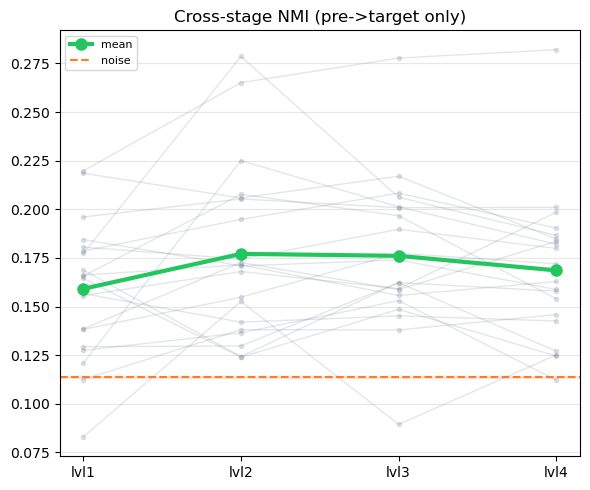

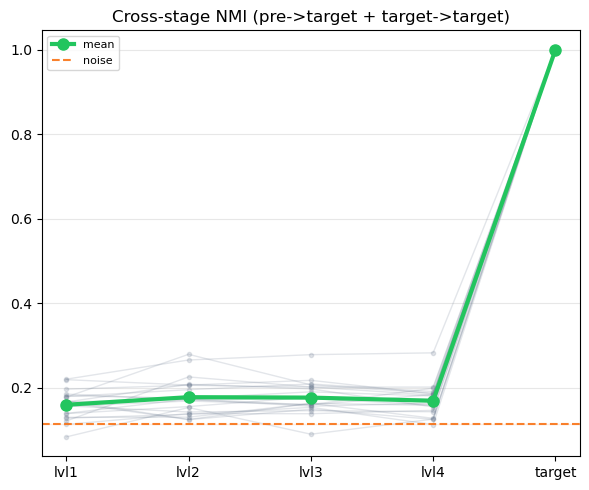

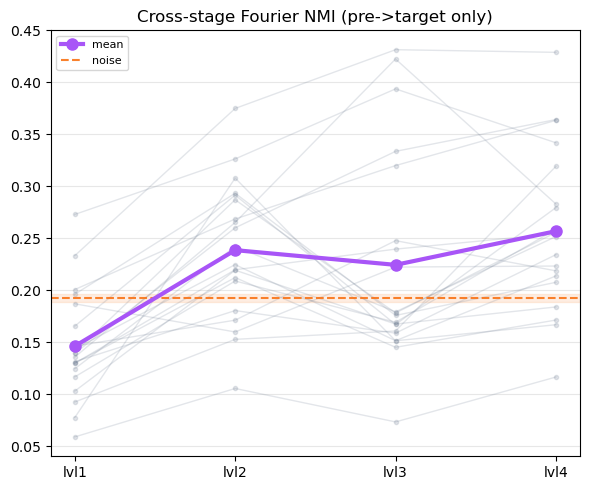

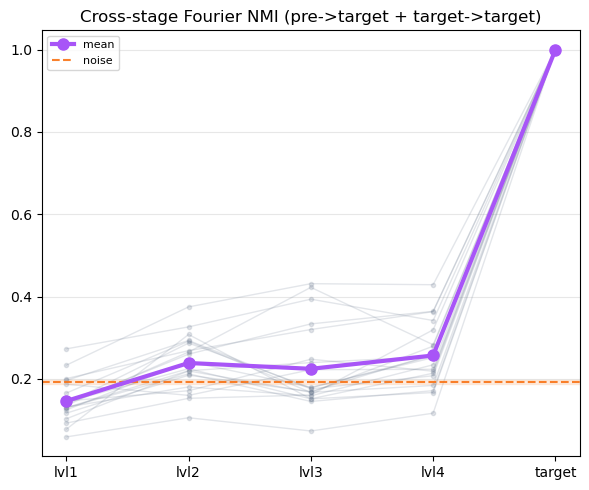

A) Cross-stage mean summary
level         SSIM       NMI   Fourier NMI
------------------------------------------
lvl1        0.1344    0.1591        0.1462
lvl2        0.1803    0.1771        0.2386
lvl3        0.0718    0.1761        0.2244
lvl4        0.0827    0.1686        0.2568
target      1.0000    1.0000        1.0000
noise       0.0783    0.1139        0.1928


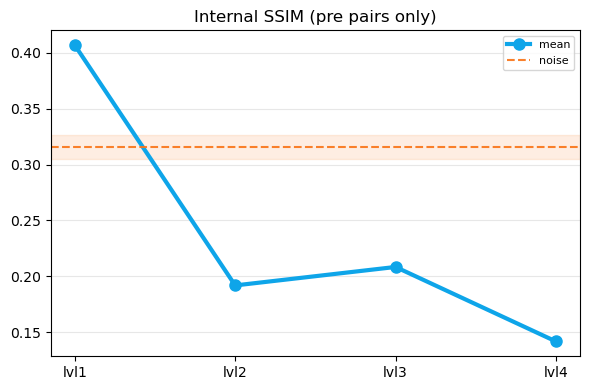

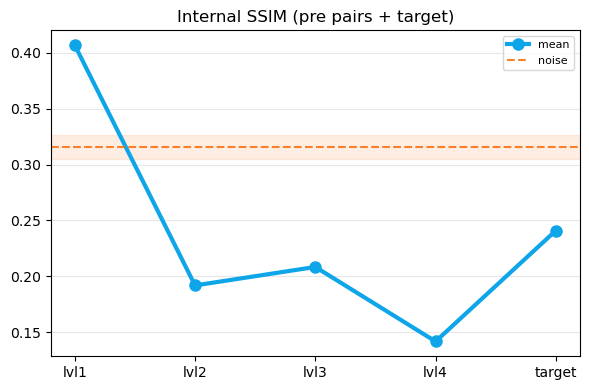

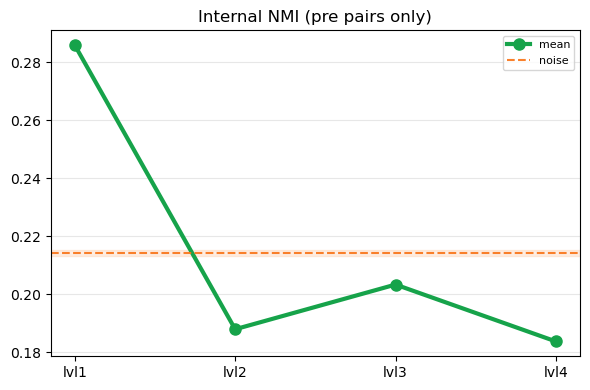

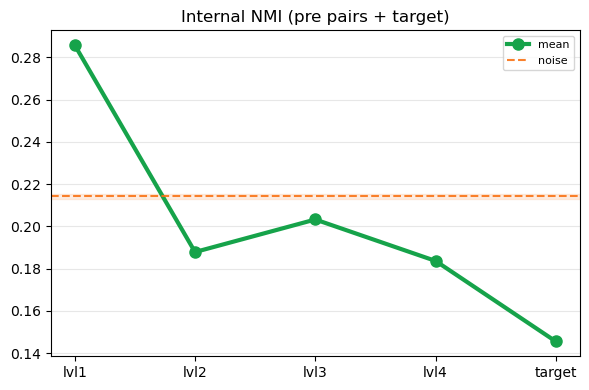

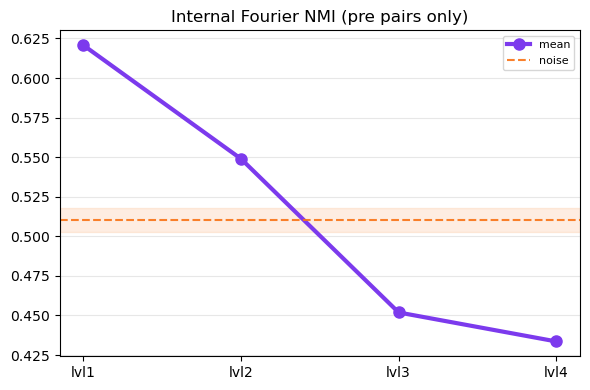

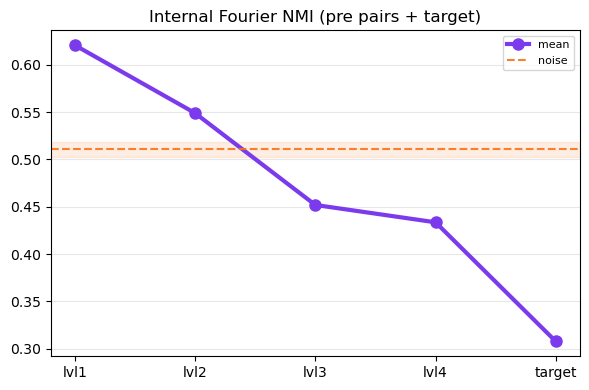

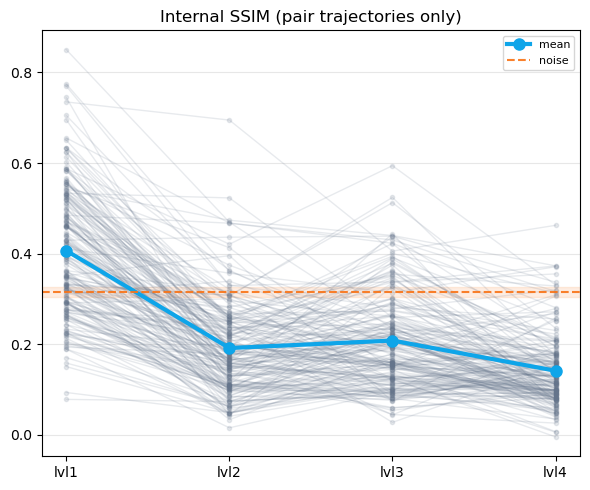

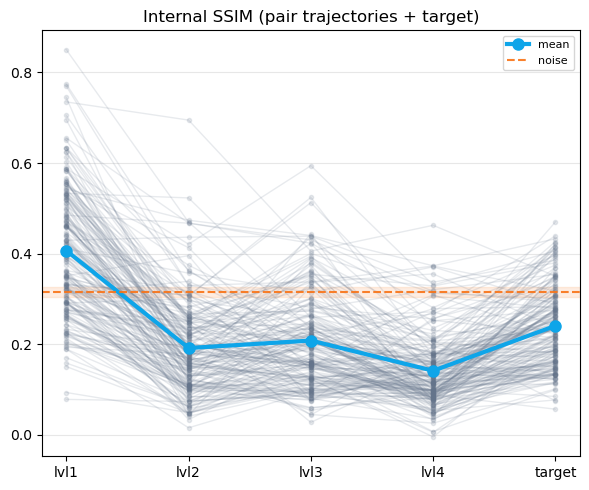

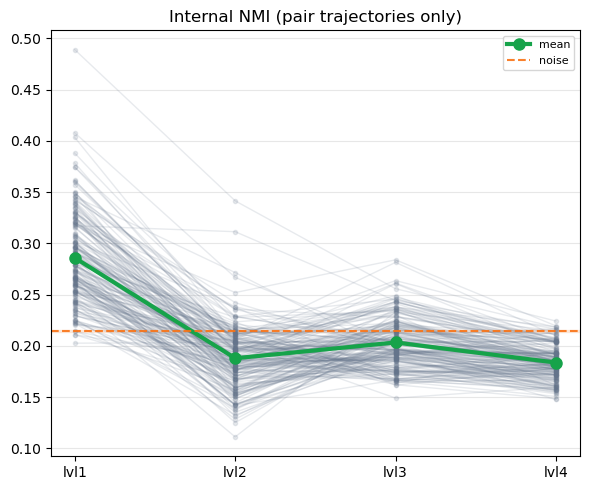

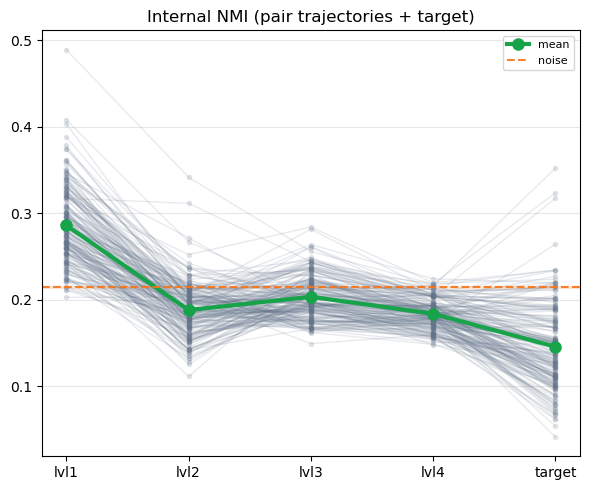

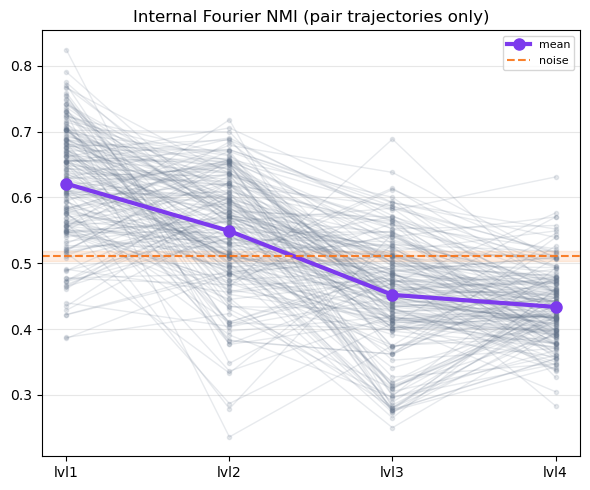

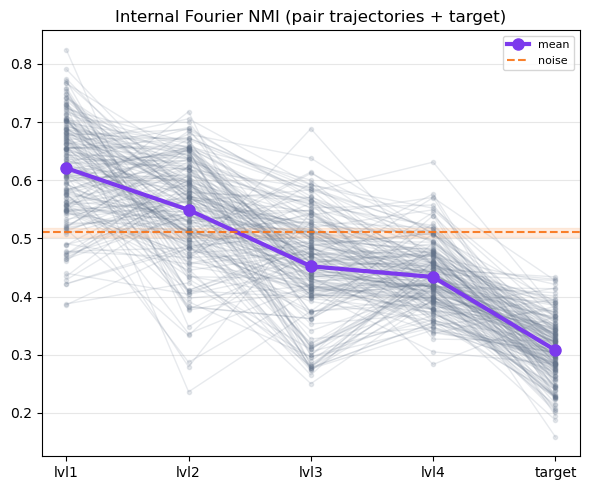

B) Cohort/internal mean summary
level       Int SSIM     Int NMI   Int Fourier NMI
----------------------------------------------------
lvl1          0.4068      0.2858            0.6208
lvl2          0.1919      0.1879            0.5490
lvl3          0.2084      0.2033            0.4519
lvl4          0.1418      0.1837            0.4336
target        0.2410      0.1455            0.3077
noise         0.3156      0.2143            0.5106


In [20]:

# ============================================================
# Similarity metrics across levels
#   A) Cross-stage (pre[k] vs target[k])
#   B) Cohort pairwise/internal (pre[i] vs pre[j])
# ============================================================
level_names = results["level_names"]
xs = np.arange(len(level_names))

target_stack = results["levels"][level_names[0]]["target"]
target_cross = ImageMetrics(target_stack, target_stack, bins=128).cross_stage_metrics()

# ------------------------------------------------------------------
# A) Cross-stage vs target metrics — one figure per metric
# ------------------------------------------------------------------
xlabels_cross_with_target = level_names + ["target"]
xs_cross_with_target = np.arange(len(xlabels_cross_with_target))
xlabels_cross_without_target = level_names
xs_cross_without_target = np.arange(len(xlabels_cross_without_target))

pair_ssim_vals = [results["levels"][k]["cross"]["mean_pair_ssim"] for k in level_names]
pair_nmi_vals = [results["levels"][k]["cross"]["mean_pair_nmi"] for k in level_names]
pair_fnmi_vals = [results["levels"][k]["cross"]["mean_pair_fourier_nmi"] for k in level_names]

cross_mean_series = [
    (pair_ssim_vals, target_cross["mean_pair_ssim"], "Cross-stage SSIM", "#3b82f6", "pair_ssim_mean", "pair_ssim_std", "cross_stage_ssim_mean"),
    (pair_nmi_vals, target_cross["mean_pair_nmi"], "Cross-stage NMI", "#22c55e", "pair_nmi_mean", "pair_nmi_std", "cross_stage_nmi_mean"),
    (pair_fnmi_vals, target_cross["mean_pair_fourier_nmi"], "Cross-stage Fourier NMI", "#a855f7", "pair_fourier_nmi_mean", "pair_fourier_nmi_std", "cross_stage_fourier_nmi_mean"),
]

for vals, target_val, base_title, color, nk_mean, nk_std, fname in cross_mean_series:
    for include_target in [False, True]:
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
        if include_target:
            plot_vals = vals + [target_val]
            plot_xs = xs_cross_with_target
            plot_labels = xlabels_cross_with_target
            title = f"{base_title} (pre->target + target->target)"
            suffix = "with_target"
        else:
            plot_vals = vals
            plot_xs = xs_cross_without_target
            plot_labels = xlabels_cross_without_target
            title = f"{base_title} (pre->target only)"
            suffix = "without_target"

        ax.plot(plot_xs, plot_vals, "o-", linewidth=3, markersize=8, color=color, label="mean")
        nm, ns = noise_baseline[nk_mean], noise_baseline[nk_std]
        ax.axhline(nm, linestyle="--", color="#f97316", alpha=0.9, label="noise")
        ax.axhspan(nm - ns, nm + ns, alpha=0.12, color="#f97316")
        ax.set_xticks(plot_xs)
        ax.set_xticklabels(plot_labels)
        ax.set_title(title)
        ax.grid(alpha=0.3, axis="y")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(figures_dir / f"{fname}_{suffix}.pdf", bbox_inches="tight")
        plt.show()

# A) Cross-stage trajectories — one figure per metric
n_imgs = len(results["levels"][level_names[0]]["cross"]["pair_ssim"])
cross_traj_series = [
    ("pair_ssim", "Cross-stage SSIM", "#3b82f6", "pair_ssim_mean", "pair_ssim_std", "cross_stage_ssim_traj"),
    ("pair_nmi", "Cross-stage NMI", "#22c55e", "pair_nmi_mean", "pair_nmi_std", "cross_stage_nmi_traj"),
    ("pair_fourier_nmi", "Cross-stage Fourier NMI", "#a855f7", "pair_fourier_nmi_mean", "pair_fourier_nmi_std", "cross_stage_fourier_nmi_traj"),
]

for key, base_title, color, nk_mean, nk_std, fname in cross_traj_series:
    for include_target in [False, True]:
        fig, ax = plt.subplots(1, 1, figsize=(6, 5))
        for img_i in range(n_imgs):
            vals_i = [results["levels"][lv]["cross"][key][img_i] for lv in level_names]
            if include_target:
                vals_i = vals_i + [target_cross[key][img_i]]
                plot_xs = xs_cross_with_target
                plot_labels = xlabels_cross_with_target
                title = f"{base_title} (pre->target + target->target)"
                suffix = "with_target"
            else:
                plot_xs = xs_cross_without_target
                plot_labels = xlabels_cross_without_target
                title = f"{base_title} (pre->target only)"
                suffix = "without_target"
            ax.plot(plot_xs, vals_i, "o-", alpha=0.18, linewidth=1, markersize=3, color="#64748b")

        mean_vals = [results["levels"][lv]["cross"][key].mean() for lv in level_names]
        if include_target:
            mean_vals = mean_vals + [target_cross[key].mean()]
        nm, ns = noise_baseline[nk_mean], noise_baseline[nk_std]
        ax.plot(plot_xs, mean_vals, "o-", linewidth=3, markersize=8, color=color, label="mean", zorder=5)
        ax.axhline(nm, linestyle="--", color="#f97316", alpha=0.9, label="noise")
        ax.axhspan(nm - ns, nm + ns, alpha=0.12, color="#f97316")
        ax.set_xticks(plot_xs)
        ax.set_xticklabels(plot_labels)
        ax.set_title(title)
        ax.grid(alpha=0.3, axis="y")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(figures_dir / f"{fname}_{suffix}.pdf", bbox_inches="tight")
        plt.show()

print("A) Cross-stage mean summary")
print(f"{'level':<8}  {'SSIM':>8}  {'NMI':>8}  {'Fourier NMI':>12}")
print("-" * 42)
for k in level_names:
    c = results["levels"][k]["cross"]
    print(f"{k:<8}  {c['mean_pair_ssim']:>8.4f}  {c['mean_pair_nmi']:>8.4f}  {c['mean_pair_fourier_nmi']:>12.4f}")
print(f"{'target':<8}  {target_cross['mean_pair_ssim']:>8.4f}  {target_cross['mean_pair_nmi']:>8.4f}  {target_cross['mean_pair_fourier_nmi']:>12.4f}")
print(f"{'noise':<8}  {noise_baseline['pair_ssim_mean']:>8.4f}  {noise_baseline['pair_nmi_mean']:>8.4f}  {noise_baseline['pair_fourier_nmi_mean']:>12.4f}")

# ------------------------------------------------------------------
# B) Cohort pairwise/internal metrics with optional target endpoint
# ------------------------------------------------------------------
xlabels_nlt_with_target = level_names + ["target"]
xs_nlt_with_target = np.arange(len(xlabels_nlt_with_target))
xlabels_nlt_without_target = level_names
xs_nlt_without_target = np.arange(len(xlabels_nlt_without_target))

internal_ssim_vals = [results["levels"][k]["pre_internal_ssim_mean"] for k in level_names]
internal_nmi_vals = [results["levels"][k]["cross"]["pre_internal_nmi_mean"] for k in level_names]
internal_fnmi_vals = [results["levels"][k]["cross"]["pre_fourier_internal_nmi_mean"] for k in level_names]
target_internal_ssim_mean = results["target"]["internal_ssim_mean"]
target_internal_nmi_mean = results["levels"][level_names[0]]["cross"]["target_internal_nmi_mean"]
target_internal_fnmi_mean = results["levels"][level_names[0]]["cross"]["target_fourier_internal_nmi_mean"]

internal_mean_series = [
    (internal_ssim_vals, target_internal_ssim_mean, "Internal SSIM", "#0ea5e9", "internal_ssim_mean", "internal_ssim_std", "internal_cohort_ssim_mean"),
    (internal_nmi_vals, target_internal_nmi_mean, "Internal NMI", "#16a34a", "internal_nmi_mean", "internal_nmi_std", "internal_cohort_nmi_mean"),
    (internal_fnmi_vals, target_internal_fnmi_mean, "Internal Fourier NMI", "#7c3aed", "fourier_internal_nmi_mean", "fourier_internal_nmi_std", "internal_cohort_fourier_nmi_mean"),
]

for vals, target_val, base_title, color, nk_mean, nk_std, fname in internal_mean_series:
    for include_target in [False, True]:
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
        if include_target:
            plot_vals = vals + [target_val]
            plot_xs = xs_nlt_with_target
            plot_labels = xlabels_nlt_with_target
            title = f"{base_title} (pre pairs + target)"
            suffix = "with_target"
        else:
            plot_vals = vals
            plot_xs = xs_nlt_without_target
            plot_labels = xlabels_nlt_without_target
            title = f"{base_title} (pre pairs only)"
            suffix = "without_target"

        ax.plot(plot_xs, plot_vals, "o-", linewidth=3, markersize=8, color=color, label="mean")
        nm, ns = noise_baseline[nk_mean], noise_baseline[nk_std]
        ax.axhline(nm, linestyle="--", color="#f97316", alpha=0.9, label="noise")
        ax.axhspan(nm - ns, nm + ns, alpha=0.12, color="#f97316")
        ax.set_xticks(plot_xs)
        ax.set_xticklabels(plot_labels)
        ax.set_title(title)
        ax.grid(alpha=0.3, axis="y")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(figures_dir / f"{fname}_{suffix}.pdf", bbox_inches="tight")
        plt.show()

# Per-pair trajectories (one line per image pair), with optional target endpoint
first_cross = results["levels"][level_names[0]]["cross"]
target_pairwise_nmi = first_cross["target_pairwise_nmi"]
target_pairwise_fnmi = first_cross["target_fourier_pairwise_nmi"]
i_idx, j_idx = np.triu_indices_from(target_pairwise_nmi, k=1)
target_internal_ssim = results["target"]["internal_ssim_values"]

internal_traj_series = [
    (
        "internal_ssim",
        "Internal SSIM",
        "#0ea5e9",
        "internal_ssim_mean",
        "internal_ssim_std",
        "internal_cohort_ssim_traj",
    ),
    (
        "internal_nmi",
        "Internal NMI",
        "#16a34a",
        "internal_nmi_mean",
        "internal_nmi_std",
        "internal_cohort_nmi_traj",
    ),
    (
        "internal_fourier_nmi",
        "Internal Fourier NMI",
        "#7c3aed",
        "fourier_internal_nmi_mean",
        "fourier_internal_nmi_std",
        "internal_cohort_fourier_nmi_traj",
    ),
]

for key, base_title, color, nk_mean, nk_std, fname in internal_traj_series:
    for include_target in [False, True]:
        fig, ax = plt.subplots(1, 1, figsize=(6, 5))

        if key == "internal_ssim":
            for pair_idx in range(len(target_internal_ssim)):
                vals = [results["levels"][lv]["pre_internal_ssim_values"][pair_idx] for lv in level_names]
                if include_target:
                    vals = vals + [target_internal_ssim[pair_idx]]
                ax.plot(
                    xs_nlt_with_target if include_target else xs_nlt_without_target,
                    vals,
                    "o-",
                    alpha=0.15,
                    linewidth=1,
                    markersize=3,
                    color="#64748b",
                )
            mean_vals = [results["levels"][lv]["pre_internal_ssim_mean"] for lv in level_names]
            if include_target:
                mean_vals = mean_vals + [results["target"]["internal_ssim_mean"]]
        elif key == "internal_nmi":
            for pair_idx in range(len(i_idx)):
                vals = [results["levels"][lv]["cross"]["pre_pairwise_nmi"][i_idx[pair_idx], j_idx[pair_idx]] for lv in level_names]
                if include_target:
                    vals = vals + [target_pairwise_nmi[i_idx[pair_idx], j_idx[pair_idx]]]
                ax.plot(
                    xs_nlt_with_target if include_target else xs_nlt_without_target,
                    vals,
                    "o-",
                    alpha=0.15,
                    linewidth=1,
                    markersize=3,
                    color="#64748b",
                )
            mean_vals = [results["levels"][lv]["cross"]["pre_internal_nmi_mean"] for lv in level_names]
            if include_target:
                mean_vals = mean_vals + [first_cross["target_internal_nmi_mean"]]
        else:
            for pair_idx in range(len(i_idx)):
                vals = [results["levels"][lv]["cross"]["pre_fourier_pairwise_nmi"][i_idx[pair_idx], j_idx[pair_idx]] for lv in level_names]
                if include_target:
                    vals = vals + [target_pairwise_fnmi[i_idx[pair_idx], j_idx[pair_idx]]]
                ax.plot(
                    xs_nlt_with_target if include_target else xs_nlt_without_target,
                    vals,
                    "o-",
                    alpha=0.15,
                    linewidth=1,
                    markersize=3,
                    color="#64748b",
                )
            mean_vals = [results["levels"][lv]["cross"]["pre_fourier_internal_nmi_mean"] for lv in level_names]
            if include_target:
                mean_vals = mean_vals + [first_cross["target_fourier_internal_nmi_mean"]]

        plot_xs = xs_nlt_with_target if include_target else xs_nlt_without_target
        plot_labels = xlabels_nlt_with_target if include_target else xlabels_nlt_without_target
        title = f"{base_title} (pair trajectories + target)" if include_target else f"{base_title} (pair trajectories only)"
        suffix = "with_target" if include_target else "without_target"

        nm, ns = noise_baseline[nk_mean], noise_baseline[nk_std]
        ax.plot(plot_xs, mean_vals, "o-", linewidth=3, markersize=8, color=color, label="mean")
        ax.axhline(nm, linestyle="--", color="#f97316", alpha=0.9, label="noise")
        ax.axhspan(nm - ns, nm + ns, alpha=0.12, color="#f97316")
        ax.set_title(title)
        ax.set_xticks(plot_xs)
        ax.set_xticklabels(plot_labels)
        ax.grid(alpha=0.3, axis="y")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(figures_dir / f"{fname}_{suffix}.pdf", bbox_inches="tight")
        plt.show()

print("B) Cohort/internal mean summary")
print(f"{'level':<8}  {'Int SSIM':>10}  {'Int NMI':>10}  {'Int Fourier NMI':>16}")
print("-" * 52)
for k in level_names:
    print(
        f"{k:<8}  "
        f"{results['levels'][k]['pre_internal_ssim_mean']:>10.4f}  "
        f"{results['levels'][k]['cross']['pre_internal_nmi_mean']:>10.4f}  "
        f"{results['levels'][k]['cross']['pre_fourier_internal_nmi_mean']:>16.4f}"
    )
print(
    f"{'target':<8}  "
    f"{results['target']['internal_ssim_mean']:>10.4f}  "
    f"{first_cross['target_internal_nmi_mean']:>10.4f}  "
    f"{first_cross['target_fourier_internal_nmi_mean']:>16.4f}"
)
print(
    f"{'noise':<8}  "
    f"{noise_baseline['internal_ssim_mean']:>10.4f}  "
    f"{noise_baseline['internal_nmi_mean']:>10.4f}  "
    f"{noise_baseline['fourier_internal_nmi_mean']:>16.4f}"
)


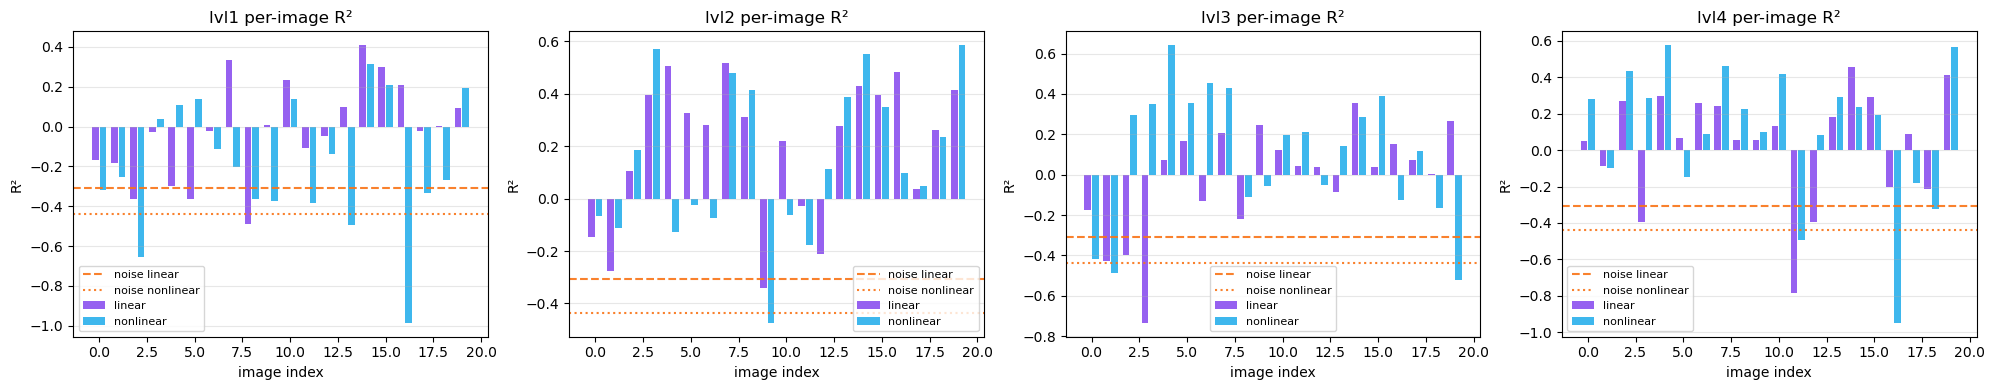

In [17]:
# Per-image R² comparison: linear vs nonlinear probe across all levels
level_names = results["level_names"]
fig, ax = plt.subplots(1, len(level_names), figsize=(5 * len(level_names), 4), squeeze=False)

for col, level_name in enumerate(level_names):
    r2_lin = results["levels"][level_name]["probe"]["r2_values"]
    r2_nl = results["levels"][level_name]["nonlinear_probe"]["r2_values"]
    img_idx = np.arange(len(r2_lin))
    ax[0, col].bar(img_idx - 0.2, r2_lin, width=0.35, label="linear", color="#7c3aed", alpha=0.8)
    ax[0, col].bar(img_idx + 0.2, r2_nl, width=0.35, label="nonlinear", color="#0ea5e9", alpha=0.8)
    ax[0, col].axhline(noise_baseline["probe_r2_mean"], linestyle="--", color="#f97316", alpha=0.9, label="noise linear")
    ax[0, col].axhline(noise_baseline["nonlinear_probe_r2_mean"], linestyle=":", color="#f97316", alpha=0.9, label="noise nonlinear")
    ax[0, col].set_title(f"{level_name} per-image R²")
    ax[0, col].set_xlabel("image index")
    ax[0, col].set_ylabel("R²")
    ax[0, col].legend(fontsize=8)
    ax[0, col].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(figures_dir / "per_image_r2_bars.pdf", bbox_inches="tight")
plt.show()
